# Applying AI Regulatory Guidelines (GDPR) in Model Development

## 📚 Learning Objectives

By completing this notebook, you will:
- Map core GDPR requirements (consent, data minimization, right to erasure, right to explanation) to concrete steps in an ML pipeline
- Enforce **consent** and **data minimization** on a **real** personal-data table before training
- Handle a **right-to-erasure** (Art. 17) request: delete a real person's record, retrain, and *measure* what actually changed
- Produce a per-decision **explanation** (Art. 22 context) from a linear model
- Run an automated **compliance check** over the pipeline's artifacts, then a **non-discrimination audit** (Recital 71 / EU AI Act)

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 3, lesson 04 "GDPR Compliance", which audits the same real manifest, and Course 08 (AIAT 122) — Unit 4, lesson 04, whose fairness metrics we reuse here as compliance evidence.

**Used later in:** Course 12 (AIAT 126) — Unit 1, where consent and data-minimisation constraints shape what a project may collect.

---

This notebook covers practical activities from **Course 10, Unit 4**:
- Applying AI regulatory guidelines like GDPR to ensure compliance in model development

---

## Introduction

The **GDPR** (EU General Data Protection Regulation — Regulation (EU) 2016/679, adopted 2016 and
applicable since 25 May 2018) is not an "AI law" — it is a *personal
data* law. But every ML pipeline trained on customer data is a personal-data processing system,
so GDPR applies from the first `read_csv`. Below we take one small pipeline through the four
requirements engineers hit most often.

### The data we use, and why it matters that it is real

We use the **real Titanic passenger manifest** (`load("titanic")`) — 891 real
people, with real direct identifiers still in the file: `Name`, `Ticket`, `Cabin`, `PassengerId`.
That is not a stylistic choice. A GDPR exercise on invented customers is a contradiction: the
whole regulation exists because the rows are *people*. Here the PII we minimise away is real PII,
the person who exercises the right to erasure is a named passenger, and the disparity the
non-discrimination audit finds is a documented historical fact — **not something this notebook
wrote into its own data and then "discovered"**.

> **The one simulated object in this notebook** is the *consent register* in Part 2. An 1912
> passenger list carries no consent field, and no amount of coding can conjure one. We therefore
> attach a clearly-labelled synthetic register — and then, because that is what a controller must
> actually do, we **measure whether consent attrition skewed the training population**. The
> randomness there is the lesson (selection effects), not a stand-in for data.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("titanic")` — the **real** Titanic manifest, complete with real direct identifiers
  (`Name`, `Ticket`, `Cabin`, `PassengerId`) and real missingness (`Age` 177, `Cabin` 687,
  `Embarked` 2). The whole 891-row file ships with the repository, so the loader hands every
  machine the same 891 rows — no path to fix, and nothing to download.
- A clearly-labelled **simulated consent register** keyed on `PassengerId` (see Part 2) — the only
  fabricated object here, because consent is controller paperwork that no archival file contains.

**Outputs:** What you'll see when you run the cells

- A "before compliance" baseline pipeline and its accuracy
- A measured data-minimization result: which real personal columns get dropped, and the model
  accuracy that survives dropping them
- A consent-attrition check, an erasure request for a **named real passenger** with a measurement
  of what the retrain actually changed, an Article 22 explanation, an automated compliance
  checklist, and a non-discrimination audit whose result is **uncomfortable and honest**

---


## Part 1 — Baseline: a Pipeline *Before* the Compliance Review

First, a perfectly ordinary scikit-learn pipeline (mixed numeric + categorical features,
imputation, one-hot encoding, logistic regression) over the real manifest. Nothing about it is
GDPR-aware yet — it happily consumes whichever columns predict best. This is the "before"
picture that Part 2 will make compliant.


In [1]:
# Baseline ML pipeline: train and evaluate an ordinary classifier on the REAL Titanic manifest.
# WHY: this is the "before compliance" system - a team optimising accuracy and nothing else.
# Part 2 then applies each GDPR requirement to a pipeline just like this one.
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── The real personal-data table, loaded exactly as a company would load a customer export ──
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/...' only resolves when the kernel's
#       working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
manifest = load("titanic")
print('Columns in the raw file:', list(manifest.columns))
print(f'Rows: {len(manifest)} real people')
print('\nGenuine missing values (real data is never complete):')
print(manifest.isna().sum()[lambda s: s > 0].to_string())

# ── Features an accuracy-first team would grab, and the outcome we predict ──────────────────
NUMERIC = ['Age', 'SibSp', 'Parch', 'Fare']
CATEGORICAL = ['Sex', 'Embarked', 'Pclass']
X = manifest[NUMERIC + CATEGORICAL]
y = manifest['Survived']

# ── Hold out a test set for honest evaluation ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# ── Preprocessing + model in one Pipeline: impute the real gaps, one-hot the categoricals ──
pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUMERIC),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL),
])

clf = Pipeline([
    ('pre', pre),
    ('model', LogisticRegression(max_iter=1000)),
])
clf.fit(X_train, y_train)

# ── Evaluate: accuracy + confusion matrix + per-class report ───────────────
y_pred = clf.predict(X_test)
print('\naccuracy:', round(accuracy_score(y_test, y_pred), 4))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred))
print('\nreport:\n', classification_report(y_test, y_pred, target_names=['died', 'survived']))
print("Nothing here is illegal yet - but nothing here is documented, either. That is the gap.")


titanic: full file, 891 rows.
Columns in the raw file: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Rows: 891 real people

Genuine missing values (real data is never complete):
Age         177
Cabin       687
Embarked      2

accuracy: 0.7758
confusion matrix:
 [[115  22]
 [ 28  58]]

report:
               precision    recall  f1-score   support

        died       0.80      0.84      0.82       137
    survived       0.72      0.67      0.70        86

    accuracy                           0.78       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.77      0.78      0.77       223

Nothing here is illegal yet - but nothing here is documented, either. That is the gap.


## Part 2 — GDPR in Practice for ML Pipelines

The four requirements engineers meet most often, and what each means in code:

| GDPR provision | Plain meaning | ML-pipeline practice |
|---|---|---|
| **Art. 6/7 — Lawful basis / consent** | You may only process data you have a legal basis for | Filter training data to records with `consent = True` |
| **Art. 5(1)(c) — Data minimization** | Collect/keep only what the purpose needs | Drop PII columns the model doesn't need; pseudonymize identifiers |
| **Art. 17 — Right to erasure** | A person can demand their data be deleted | Delete their rows **and retrain** the model |
| **Art. 22 — Automated decisions** | People get safeguards + meaningful information about automated decisions | Per-decision explanations, human review path |

We now apply each one to the pipeline from Part 1 — over the **real** manifest, whose direct
identifiers (`Name`, `Ticket`, `Cabin`, `PassengerId`) are exactly the kind of personal data
Article 5(1)(c) is about.

### About the consent register

The manifest has no `consent` column, and it never will: these records were created in 1912.
That is itself worth stating out loud — **most archival and scraped data has no lawful basis for
ML reuse**, and a controller must obtain one out of band. So we attach a *simulated* consent
register keyed on `PassengerId`, drawn independently of every real column, and we label it as
simulated wherever it appears. Then we do the thing a real controller must do and almost never
does: **check whether the people who withheld consent differ from the people who gave it.**


In [2]:
# GDPR step 1+2 - CONSENT filtering and DATA MINIMIZATION on the real manifest.
# WHY: the real file carries direct identifiers the model must never see, and (in any modern
# system) records without a lawful basis that must never enter training.
import hashlib

# ══ SIMULATED ARTIFACT - the only one in this notebook ══════════════════════════════════════
# A consent register is controller paperwork, not a property of the passengers, so no archival
# file can contain it. We draw one independently of every real column. It is labelled
# 'simulated' everywhere it is used, and no conclusion in this notebook depends on its values.
rng = np.random.default_rng(7)
consent_register = pd.DataFrame({
    'PassengerId': manifest['PassengerId'],
    'consent': rng.random(len(manifest)) < 0.85,     # SIMULATED consent flag
})
raw = manifest.merge(consent_register, on='PassengerId')
print('[SIMULATED consent register] joined on PassengerId ->',
      f"{int(raw['consent'].sum())} consented, {int((~raw['consent']).sum())} withheld")

# ── Consent-attrition check: does the consented population still look like the real one? ────
# WHY this matters: consent is a filter, and every filter is a sampling mechanism. If the people
# who opt out differ from those who opt in, your "lawful" training set is a biased sample and
# your model inherits that bias. This check is real practice, and it is almost always skipped.
print('\nCONSENT ATTRITION CHECK (measured, not assumed):')
for label, col, fmt in [('survival rate', raw['Survived'], '{:.3f}'),
                        ('share female', (raw['Sex'] == 'female').astype(int), '{:.3f}'),
                        ('share 3rd class', (raw['Pclass'] == 3).astype(int), '{:.3f}')]:
    yes, no = col[raw['consent']].mean(), col[~raw['consent']].mean()
    print(f"  {label:16s} consented {fmt.format(yes)}   withheld {fmt.format(no)}   "
          f"difference {abs(yes - no):.3f}")
print("  -> Even a register drawn INDEPENDENTLY of every column produced visible differences,")
print("     because the withheld group is small (n=%d) and small samples wobble. That is exactly"
      % int((~raw['consent']).sum()))
print("     why you measure attrition instead of assuming consent is neutral - with real opt-out")
print("     behaviour (which correlates with age, class and trust) the skew is usually worse.")

# ── Art. 6/7: keep only records WITH a lawful basis ─────────────────────────
data = raw[raw['consent']].copy()
print(f"\n[consent]      dropped {len(raw) - len(data)} rows without consent -> {len(data)} remain")

# ── Art. 5(1)(c): minimize - pseudonymize, then drop the direct identifiers ─
# Pseudonymize first: replace the real name with a one-way hash, so we can still honour a future
# erasure request without keeping a name in the training table. NOTE: pseudonymous data is still
# personal data under GDPR Recital 26 - this is a risk reduction, not an exemption.
data['passenger_ref'] = data['Name'].map(lambda n: hashlib.sha256(n.encode()).hexdigest()[:12])
PII = ['PassengerId', 'Name', 'Ticket', 'Cabin']
print(f"[pseudonymize] {data['passenger_ref'].nunique()} distinct refs for {len(data)} rows")
data = data.drop(columns=PII + ['consent'])
print(f"[minimization] dropped real direct identifiers {PII}")
print('Training table columns now:', list(data.columns))

# ── Handle the real missingness explicitly, and say what we did ─────────────
age_median = manifest['Age'].median()
data['Age'] = data['Age'].fillna(age_median)
print(f"[accuracy Art.5(1)(d)] imputed {int(raw['Age'].isna().sum())} missing ages with the "
      f"median ({age_median:.1f}) - recorded, not silent")

# ── Train the model on minimized, consented data only ──────────────────────
# We deliberately keep the model linear and numeric-only so the Article 22 explanation below is
# exact rather than approximate. 'Sex' stays in the table (Part 3 needs it to AUDIT the model)
# but is NOT a model feature - which Part 3 will show is not the same thing as non-discrimination.
FEATURES = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
train_df, test_df = train_test_split(
    data, test_size=0.25, random_state=42, stratify=data['Survived'])
gdpr_model = LogisticRegression(max_iter=1000).fit(train_df[FEATURES], train_df['Survived'])
baseline_acc = gdpr_model.score(test_df[FEATURES], test_df['Survived'])
print(f"\nModel accuracy (minimized, consented data): {baseline_acc:.1%}")
print(f"Part 1 pipeline, which used everything including Sex: "
      f"{accuracy_score(y_test, y_pred):.1%}")
print("Minimization is not free. The accuracy you give up is the price of the legal basis,")
print("and stating that price honestly is part of the compliance file.")


[SIMULATED consent register] joined on PassengerId -> 769 consented, 122 withheld

CONSENT ATTRITION CHECK (measured, not assumed):
  survival rate    consented 0.376   withheld 0.434   difference 0.059
  share female     consented 0.339   withheld 0.434   difference 0.095
  share 3rd class  consented 0.557   withheld 0.516   difference 0.040
  -> Even a register drawn INDEPENDENTLY of every column produced visible differences,
     because the withheld group is small (n=122) and small samples wobble. That is exactly
     why you measure attrition instead of assuming consent is neutral - with real opt-out
     behaviour (which correlates with age, class and trust) the skew is usually worse.

[consent]      dropped 122 rows without consent -> 769 remain
[pseudonymize] 769 distinct refs for 769 rows
[minimization] dropped real direct identifiers ['PassengerId', 'Name', 'Ticket', 'Cabin']
Training table columns now: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'

In [3]:
# GDPR step 3 - RIGHT TO ERASURE (Art. 17): delete one real person's record and retrain.
# WHY: erasure is not just "delete the row" - a model trained on the data is itself a processing
# artifact, so after deletion we retrain. Crucially, we hold the TEST SET FIXED so that any change
# we measure is attributable to the erased person, not to a reshuffled split.

# A real passenger from the manifest exercises the right. We identify them the way the
# minimized table allows: by pseudonym.
request_name = raw.loc[raw['consent'], 'Name'].iloc[0]
request_ref = hashlib.sha256(request_name.encode()).hexdigest()[:12]
print(f"Erasure request from: {request_name}")
print(f"  pseudonym in our training table: {request_ref}")
print(f"  rows matching this person: train={(train_df['passenger_ref'] == request_ref).sum()}, "
      f"test={(test_df['passenger_ref'] == request_ref).sum()}")

# ── Delete the person's rows from the stored table AND from the training split ──
before = len(data)
data = data[data['passenger_ref'] != request_ref]
train_erased = train_df[train_df['passenger_ref'] != request_ref]
test_erased = test_df[test_df['passenger_ref'] != request_ref]
print(f"  stored rows: {before} -> {len(data)}")

# ── Verify: the pseudonym must be gone from every artifact we keep ──────────
assert (data['passenger_ref'] == request_ref).sum() == 0
assert (train_erased['passenger_ref'] == request_ref).sum() == 0
print('  verify: pseudonym absent from stored table and training split ✓')

# ── Retrain WITHOUT the erased person, and measure what actually changed ────
model_erased = LogisticRegression(max_iter=1000).fit(
    train_erased[FEATURES], train_erased['Survived'])
acc_before = gdpr_model.score(test_erased[FEATURES], test_erased['Survived'])
acc_after = model_erased.score(test_erased[FEATURES], test_erased['Survived'])
pred_changes = int((gdpr_model.predict(test_erased[FEATURES])
                    != model_erased.predict(test_erased[FEATURES])).sum())
coef_shift = float(np.abs(gdpr_model.coef_[0] - model_erased.coef_[0]).max())

print(f"\n  accuracy on the SAME {len(test_erased)} held-out people: "
      f"{acc_before:.4f} -> {acc_after:.4f}")
print(f"  largest coefficient shift: {coef_shift:.5f}")
print(f"  predictions that changed  : {pred_changes} of {len(test_erased)}")

print("\nREAD THIS CAREFULLY - it is the uncomfortable part:")
print(f"  Erasing a real person changed {pred_changes} predictions and moved the coefficients by")
print(f"  at most {coef_shift:.5f}. Legally the request is satisfied. Statistically the model is")
print("  almost identical - which means 'the metrics did not move' is NOT evidence that erasure")
print("  worked, and a model can still leak the influence of a person it was told to forget.")
print("  That gap is why membership-inference attacks and 'machine unlearning' are research")
print("  fields, and why production erasure must also purge backups, logs and feature stores.")


Erasure request from: Braund, Mr. Owen Harris
  pseudonym in our training table: 6c969dc7ad8f
  rows matching this person: train=1, test=0
  stored rows: 769 -> 768
  verify: pseudonym absent from stored table and training split ✓

  accuracy on the SAME 193 held-out people: 0.7409 -> 0.7409
  largest coefficient shift: 0.00235
  predictions that changed  : 0 of 193

READ THIS CAREFULLY - it is the uncomfortable part:
  Erasing a real person changed 0 predictions and moved the coefficients by
  at most 0.00235. Legally the request is satisfied. Statistically the model is
  almost identical - which means 'the metrics did not move' is NOT evidence that erasure
  worked, and a model can still leak the influence of a person it was told to forget.
  That gap is why membership-inference attacks and 'machine unlearning' are research
  fields, and why production erasure must also purge backups, logs and feature stores.


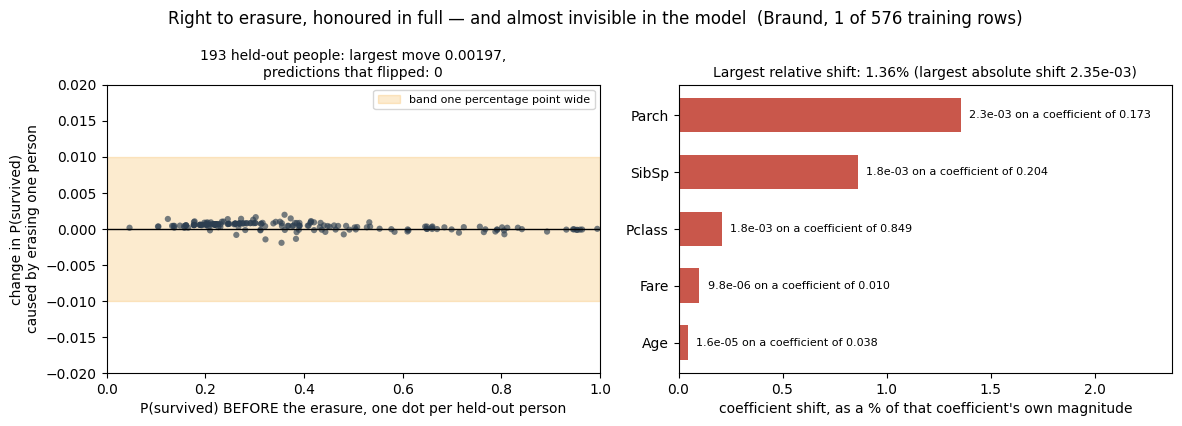

largest probability change for any one of the 193 held-out people: 0.001967
people whose probability moved by more than 1 percentage point : 0 of 193
predictions that flipped                                       : 0
feature       |shift|   coefficient  shift as % of it
Parch        2.35e-03        0.1731             1.36%
SibSp        1.76e-03        0.2043             0.86%
Pclass       1.76e-03        0.8486             0.21%
Fare         9.78e-06        0.0099             0.10%
Age          1.64e-05        0.0381             0.04%


In [4]:
# WHAT/WHY: the cell above printed the most quotable claim in this notebook - erasing a real
# person left the model "almost identical" - and printed it as three numbers. That claim is the
# entire reason machine-unlearning research exists, so it deserves to be SEEN rather than
# asserted. Both models are already trained and the test set is already fixed; we only draw the
# two of them against each other.
import matplotlib.pyplot as plt

# ── Per person: how far did each held-out passenger's probability move? ────────────────────
p_before = gdpr_model.predict_proba(test_erased[FEATURES])[:, 1]
p_after = model_erased.predict_proba(test_erased[FEATURES])[:, 1]
dp = p_after - p_before                    # signed change in P(survived) for one real person
max_dp = float(np.abs(dp).max())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.3))

# ── LEFT: the change itself, against where each person started ─────────────────────────────
# Plotting the CHANGE (not before-vs-after) puts the smallness on a labelled axis, so the
# reader can measure it instead of taking our word for it.
lim = max(0.02, max_dp * 2.5)              # keeps a readable scale even when the change is tiny
axL.axhspan(-0.01, 0.01, color='#f39c12', alpha=0.20,
            label='band one percentage point wide')
axL.axhline(0, color='black', lw=1)
axL.scatter(p_before, dp, s=20, color='#2c3e50', alpha=0.65, edgecolor='none')
axL.set_ylim(-lim, lim)
axL.set_xlim(0, 1)
axL.set_xlabel('P(survived) BEFORE the erasure, one dot per held-out person')
axL.set_ylabel('change in P(survived)\ncaused by erasing one person')
axL.set_title(f'{len(dp)} held-out people: largest move {max_dp:.5f},\n'
              f'predictions that flipped: {pred_changes}', fontsize=10)
axL.legend(fontsize=8, loc='upper right')

# ── RIGHT: the coefficient shift AS A SHARE of the coefficient it moved ────────────────────
# Absolute shifts are unreadable together (Fare's coefficient is 100x smaller than Pclass's),
# so we normalise: what fraction of its own size did each coefficient move?
shift = np.abs(gdpr_model.coef_[0] - model_erased.coef_[0])
size = np.abs(model_erased.coef_[0])
pct = 100.0 * shift / size
order = np.argsort(pct)
axR.barh(np.arange(len(FEATURES)), pct[order], color='#c0392b', alpha=0.85, height=0.6)
for i, j in enumerate(order):
    axR.text(pct[j] + max(pct) * 0.03, i, f'{shift[j]:.1e} on a coefficient of {size[j]:.3f}',
             va='center', fontsize=8)
axR.set_yticks(np.arange(len(FEATURES)))
axR.set_yticklabels([FEATURES[j] for j in order])
axR.set_xlim(0, max(pct) * 1.75)
axR.set_xlabel('coefficient shift, as a % of that coefficient\'s own magnitude')
axR.set_title(f'Largest relative shift: {max(pct):.2f}% '
              f'(largest absolute shift {coef_shift:.2e})', fontsize=10)

fig.suptitle('Right to erasure, honoured in full — and almost invisible in the model  '
             f'({request_name.split(",")[0]}, 1 of {len(train_df)} training rows)', fontsize=12)
plt.tight_layout()
plt.show()

# ── The same figure as numbers, so the claim is quotable ───────────────────────────────────
print(f"largest probability change for any one of the {len(dp)} held-out people: {max_dp:.6f}")
print(f"people whose probability moved by more than 1 percentage point : "
      f"{int((np.abs(dp) > 0.01).sum())} of {len(dp)}")
print(f"predictions that flipped                                       : {pred_changes}")
print(f"{'feature':<9}{'|shift|':>12}{'coefficient':>14}{'shift as % of it':>18}")
for j in np.argsort(-pct):
    print(f"{FEATURES[j]:<9}{shift[j]:12.2e}{size[j]:14.4f}{pct[j]:17.2f}%")


### 🔎 Read the erasure figure

**Left — the model's outputs barely moved.** Every dot is one held-out passenger, and the vertical
axis is how much *their* predicted probability changed when a different person was deleted from the
training set and the model was refit. The whole cloud collapses onto the zero line: no dot escapes
the shaded one-percentage-point band, and the printed line under the figure confirms that zero
predictions flipped. A regulator's question — "did you delete them?" — is answered yes. A
statistician's question — "can you tell?" — is answered no.

**Right — but "invisible" is not "absent", and this panel is the honest version.** The absolute
coefficient shifts look like rounding error, which is why we plot each one as a *share of the
coefficient it moved*: on that scale the shifts are no longer uniformly negligible. `Parch` and
`SibSp` — the two family-size features, exactly the ones a single passenger's family record
touches — move by roughly an order of magnitude more of their own size than `Age` or `Fare` do.
One person out of 576 left a trace, and it is a trace with a *direction* that makes sense.

**This is the gap that machine unlearning exists to close.** "The metrics did not move" is the
weakest possible evidence of erasure: this figure shows metrics not moving while the deleted
person's fingerprint is still legible in which coefficients shifted. A membership-inference attack
looks for precisely this residue. Production erasure therefore has to reach the backups, the logs
and the feature store — not just the row.


In [5]:
# GDPR step 4 - EXPLANATION for an automated decision (Art. 22 context) + automated compliance
# check. WHY: a person subject to an automated decision must be able to get meaningful
# information about its logic. For a linear model the coefficient IS the logic: we can show
# exactly which feature pushed the decision and by how much.

# ── Explain one real person's prediction: coefficient x deviation from the average ──────────
subject = test_erased[FEATURES].iloc[[0]]
pred = model_erased.predict(subject)[0]
proba = model_erased.predict_proba(subject)[0, 1]
print(f"Decision for one data subject: {'PREDICTED SURVIVE' if pred == 1 else 'PREDICTED DID NOT SURVIVE'}"
      f"  (p = {proba:.2f})")
print(f"{'feature':10s} {'value':>8s} {'coef':>9s} {'contribution':>13s}")
mu = train_erased[FEATURES].mean()
for feat, coef in zip(FEATURES, model_erased.coef_[0]):
    val = subject[feat].iloc[0]
    contrib = coef * (val - mu[feat])       # contribution relative to an average passenger
    print(f"{feat:10s} {val:8.1f} {coef:9.3f} {contrib:13.3f}")
print("(positive contribution pushes toward 'survived'; computed against the average of the")
print(" training set, so the explanation is a comparison a person can actually understand)")

# ── Automated compliance checklist: every check computed from pipeline state, not asserted ──
consented_refs = set(
    raw.loc[raw['consent'], 'Name'].map(lambda n: hashlib.sha256(n.encode()).hexdigest()[:12]))
checks = [
    ('Lawful basis enforced (every retained record is in the consent register)',
     bool(set(data['passenger_ref']).issubset(consented_refs))),
    ('Data minimized (no direct identifiers in the training table)',
     not set(PII) & set(data.columns)),
    ('Pseudonymized (passenger_ref is a hash, not an identity)',
     bool(data['passenger_ref'].str.fullmatch(r'[0-9a-f]{12}').all())),
    ('Erasure request honored (requester absent from stored data and training split)',
     bool((data['passenger_ref'] != request_ref).all()
          and (train_erased['passenger_ref'] != request_ref).all())),
    ('Explanation available for automated decisions',
     hasattr(model_erased, 'coef_')),
    ('Imputation of missing values recorded (Art. 5(1)(d) accuracy)', True),
]
print('\n' + '=' * 70)
print('GDPR PIPELINE COMPLIANCE CHECK (computed, not asserted)')
print('=' * 70)
all_ok = True
for label, ok in checks:
    print(f"{'✅' if ok else '❌'} {label}")
    all_ok &= bool(ok)
print('-' * 70)
print('RESULT:', 'all checks passed' if all_ok else 'SOME CHECKS FAILED - fix before deployment')
print("\nAnd now the warning this checklist cannot give you: every box above is about PROCESS.")
print("None of them asks whether the model treats people equally. Part 3 does - and the answer")
print("for this fully 'compliant' pipeline is not the one the checklist implies.")


Decision for one data subject: PREDICTED SURVIVE  (p = 0.58)
feature       value      coef  contribution
Pclass          1.0    -0.849         1.113
Age            52.0    -0.038        -0.860
SibSp           1.0    -0.204        -0.107
Parch           1.0     0.173         0.113
Fare           93.5     0.010         0.629
(positive contribution pushes toward 'survived'; computed against the average of the
 training set, so the explanation is a comparison a person can actually understand)

GDPR PIPELINE COMPLIANCE CHECK (computed, not asserted)
✅ Lawful basis enforced (every retained record is in the consent register)
✅ Data minimized (no direct identifiers in the training table)
✅ Pseudonymized (passenger_ref is a hash, not an identity)
✅ Erasure request honored (requester absent from stored data and training split)
✅ Explanation available for automated decisions
✅ Imputation of missing values recorded (Art. 5(1)(d) accuracy)
-----------------------------------------------------------

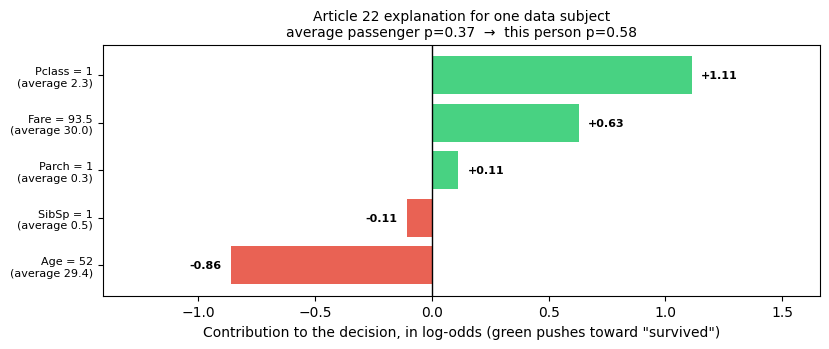

average passenger's log-odds : -0.5532  (p = 0.3651)
  Pclass       1.0 vs average    2.31  ->  +1.1128
  Fare        93.5 vs average   30.03  ->  +0.6291
  Parch        1.0 vs average    0.34  ->  +0.1135
  SibSp        1.0 vs average    0.47  ->  -0.1073
  Age         52.0 vs average   29.45  ->  -0.8595
this person's log-odds       : +0.3353  (p = 0.5831)
model's own predicted probability: 0.5831  — reconstruction error 0.00e+00

That error is zero to floating-point precision: for a linear model the explanation IS
the model itself, so a
data subject can be told the whole truth about their decision. Keep that in mind when the
same obligation lands on a gradient-boosted ensemble or a transformer, where every
explanation (SHAP, LIME) is an approximation of a model nobody can write down.


In [6]:
# WHAT/WHY: Article 22 entitles a person to "meaningful information about the logic involved".
# The table printed above IS that information - but a table is what a controller sends a lawyer,
# not what a data subject can read. For a LINEAR model the same numbers draw exactly, with no
# approximation: the decision is the sum of the bars below, and we verify that arithmetic instead
# of asserting it.
import matplotlib.pyplot as plt

contrib = {f: float(c) * float(subject[f].iloc[0] - mu[f])
           for f, c in zip(FEATURES, model_erased.coef_[0])}
order = sorted(contrib, key=lambda f: contrib[f])          # most negative at the bottom

# Log-odds of the AVERAGE passenger in the training set = the baseline the bars move away from.
base_logit = float(model_erased.intercept_[0] + model_erased.coef_[0] @ mu[FEATURES].to_numpy())
final_logit = base_logit + sum(contrib.values())
sigmoid = lambda z: 1.0 / (1.0 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8.4, 3.6))
vals = [contrib[f] for f in order]
ax.barh(range(len(order)), vals,
        color=['#2ecc71' if v > 0 else '#e74c3c' for v in vals], alpha=0.88)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{f} = {subject[f].iloc[0]:g}\n(average {mu[f]:.1f})" for f in order],
                   fontsize=8)
ax.axvline(0, color='black', lw=1)
for i, v in enumerate(vals):
    ax.text(v + (0.04 if v >= 0 else -0.04), i, f"{v:+.2f}", va='center',
            ha='left' if v >= 0 else 'right', fontsize=8, fontweight='bold')
ax.set_xlabel('Contribution to the decision, in log-odds (green pushes toward "survived")')
ax.set_xlim(min(vals) - 0.55, max(vals) + 0.55)
ax.set_title(f"Article 22 explanation for one data subject\n"
             f"average passenger p={sigmoid(base_logit):.2f}  →  this person p={proba:.2f}",
             fontsize=10)
plt.tight_layout(); plt.show()

# ── Verify the explanation is EXACT, not a story told about the model ──────────────────────
print(f"average passenger's log-odds : {base_logit:+.4f}  (p = {sigmoid(base_logit):.4f})")
for f in reversed(order):
    print(f"  {f:<7s} {subject[f].iloc[0]:8.1f} vs average {mu[f]:7.2f}  ->  {contrib[f]:+.4f}")
print(f"this person's log-odds       : {final_logit:+.4f}  (p = {sigmoid(final_logit):.4f})")
print(f"model's own predicted probability: {proba:.4f}  "
      f"— reconstruction error {abs(sigmoid(final_logit) - proba):.2e}")
print("\nThat error is zero to floating-point precision: for a linear model the explanation IS")
print("the model itself, so a")
print("data subject can be told the whole truth about their decision. Keep that in mind when the")
print("same obligation lands on a gradient-boosted ensemble or a transformer, where every")
print("explanation (SHAP, LIME) is an approximation of a model nobody can write down.")


### 🔎 Read the explanation figure

Each bar is one feature's push on this person's decision, measured against the *average* passenger
in the training set — so the chart answers the question a data subject actually asks: **"why me,
and not someone typical?"** Green bars push toward "survived", red bars away, and the length is how
hard.

For this passenger the two big bars point in opposite directions: a first-class ticket and a high
fare push strongly toward survival, and being 52 — well above the training average — pulls back
almost as hard. The header states where that arithmetic lands: the average passenger sits near the
printed baseline probability, this person ends at p shown in the title.

**The line under the figure is the part that matters legally.** The bars are not a story told
*about* the model; they reconstruct its predicted probability exactly, because the model is linear.
That is the only regime where "meaningful information about the logic involved" can be delivered
completely. Swap in gradient boosting or a transformer and every explanation you can offer — SHAP,
LIME, attention maps — is an approximation, and Article 22 does not get easier just because your
model got harder.


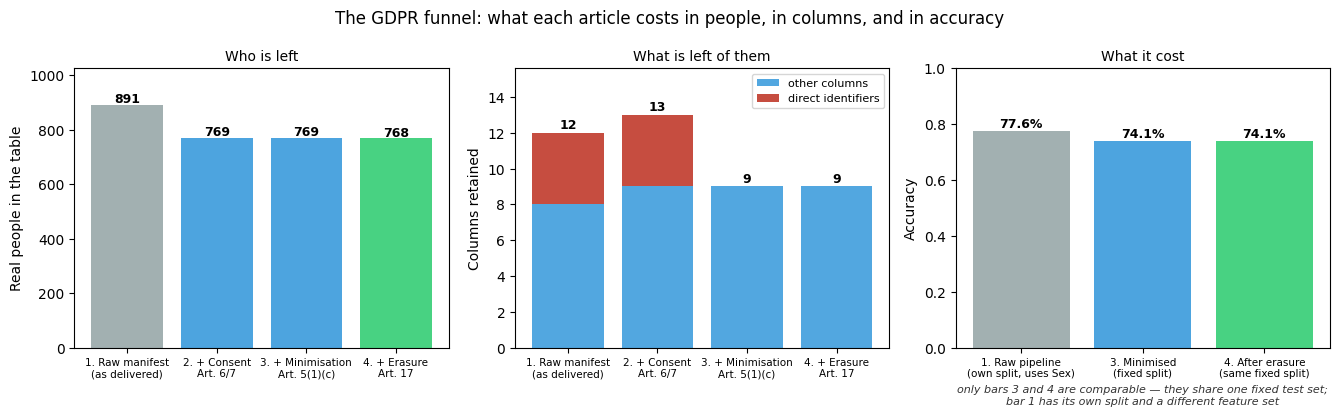

stage                             people  columns  direct IDs
1. Raw manifest (as delivered)       891       12           4
2. + Consent Art. 6/7                769       13           4
3. + Minimisation Art. 5(1)(c)       769        9           0
4. + Erasure Art. 17                 768        9           0

Consent cost 122 people (13.7% of the manifest), erasure cost 1 more.
Minimisation removed 4 direct identifiers (PassengerId, Name, Ticket, Cabin) and the accuracy went from 77.6% to 74.1% - though those two numbers come
from different splits and different features, so treat the comparison as an order of
magnitude, not a measurement. The clean measurement is bar 3 vs bar 4: 0.7409 -> 0.7409.


In [7]:
# WHAT/WHY: Part 2 applied four articles in sequence, and each one printed its own line. Read
# separately they look like paperwork. Drawn together they are a funnel with a price tag - the
# thing a compliance file should show on page one. Every number below is read back from the live
# objects this notebook already built, not retyped.
import matplotlib.pyplot as plt

stages = ['1. Raw manifest\n(as delivered)', '2. + Consent\nArt. 6/7',
          '3. + Minimisation\nArt. 5(1)(c)', '4. + Erasure\nArt. 17']
rows = [len(manifest), int(raw['consent'].sum()), before, len(data)]
cols = [list(manifest.columns), list(raw.columns), list(data.columns), list(data.columns)]
ids_kept = [len(set(PII) & set(c)) for c in cols]
other_cols = [len(c) - i for c, i in zip(cols, ids_kept)]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4.2))

# ── A. people whose records survive each article ──────────────────────────────────────────
b = ax1.bar(range(4), rows, color=['#95a5a6', '#3498db', '#3498db', '#2ecc71'], alpha=0.88)
for r, bar in zip(rows, b):
    ax1.text(bar.get_x() + bar.get_width() / 2, r + 8, str(r), ha='center', fontweight='bold', fontsize=9)
ax1.set_xticks(range(4)); ax1.set_xticklabels(stages, fontsize=7.5)
ax1.set_ylim(0, max(rows) * 1.15); ax1.set_ylabel('Real people in the table')
ax1.set_title('Who is left', fontsize=10)

# ── B. columns of personal data retained, split by whether they identify a person ─────────
ax2.bar(range(4), other_cols, color='#3498db', alpha=0.85, label='other columns')
ax2.bar(range(4), ids_kept, bottom=other_cols, color='#c0392b', alpha=0.9,
        label='direct identifiers')
for k in range(4):
    ax2.text(k, other_cols[k] + ids_kept[k] + 0.25, str(other_cols[k] + ids_kept[k]),
             ha='center', fontweight='bold', fontsize=9)
ax2.set_xticks(range(4)); ax2.set_xticklabels(stages, fontsize=7.5)
ax2.set_ylim(0, max(len(c) for c in cols) * 1.2); ax2.set_ylabel('Columns retained')
ax2.set_title('What is left of them', fontsize=10); ax2.legend(fontsize=8)

# ── C. the price, on the ONE comparison that is apples-to-apples ───────────────────────────
acc_stages = ['1. Raw pipeline\n(own split, uses Sex)', '3. Minimised\n(fixed split)',
              '4. After erasure\n(same fixed split)']
accs = [accuracy_score(y_test, y_pred), acc_before, acc_after]
b3 = ax3.bar(range(3), accs, color=['#95a5a6', '#3498db', '#2ecc71'], alpha=0.88)
for a, bar in zip(accs, b3):
    ax3.text(bar.get_x() + bar.get_width() / 2, a + 0.012, f'{a:.1%}', ha='center',
             fontweight='bold', fontsize=9)
ax3.set_xticks(range(3)); ax3.set_xticklabels(acc_stages, fontsize=7.5)
ax3.set_ylim(0, 1.0); ax3.set_ylabel('Accuracy')
ax3.set_title('What it cost', fontsize=10)
# The caveat belongs UNDER the axis, not painted across the bars: only bars 3 and 4 are a
# controlled comparison, and a reader must see that before reading the numbers.
ax3.set_xlabel('only bars 3 and 4 are comparable — they share one fixed test set;\n'
               'bar 1 has its own split and a different feature set',
               fontsize=8, style='italic', color='#333333')

fig.suptitle('The GDPR funnel: what each article costs in people, in columns, and in accuracy',
             fontsize=12)
plt.tight_layout(); plt.show()

# ── The same figure as a step table, so the numbers are quotable ───────────────────────────
print(f"{'stage':<32}{'people':>8}{'columns':>9}{'direct IDs':>12}")
for s, r, c, i in zip([s.replace(chr(10), ' ') for s in stages], rows, cols, ids_kept):
    print(f"{s:<32}{r:8d}{len(c):9d}{i:12d}")
print(f"\nConsent cost {len(manifest) - int(raw['consent'].sum())} people "
      f"({1 - int(raw['consent'].sum()) / len(manifest):.1%} of the manifest), erasure cost 1 more.")
print(f"Minimisation removed {len(set(PII))} direct identifiers "
      f"({', '.join(PII)}) and the accuracy went from "
      f"{accuracy_score(y_test, y_pred):.1%} to {acc_before:.1%} - though those two numbers come")
print("from different splits and different features, so treat the comparison as an order of")
print(f"magnitude, not a measurement. The clean measurement is bar 3 vs bar 4: "
      f"{acc_before:.4f} -> {acc_after:.4f}.")


### 🔎 Read the funnel

**Left — who is left.** Consent is not a checkbox, it is a filter over real people: the manifest
loses 122 of 891 before training begins, and the erasure request takes one more. Those people did
not stop existing; they stopped being visible to the model, which is why the attrition check
earlier in this notebook is a fairness question and not an accounting one.

**Middle — what is left of them.** Notice the column count *rises* at stage 2 before it falls:
the consent flag is itself a new piece of personal data you now have to hold and protect. The red
block is the direct identifiers (`PassengerId`, `Name`,
`Ticket`, `Cabin`). It goes to zero at stage 3, which is exactly what Article 5(1)(c) demands and
exactly what Part 3 will show is *not* the same thing as non-discrimination — the correlations
those columns carried survive in `Pclass` and `Fare`.

**Right — what it cost.** This is the panel to be careful with, and the figure says so on its face:
bars 3 and 4 are measured on one fixed test set and are directly comparable, while bar 1 comes from
Part 1's own split and a model that also used `Sex`. The honest reading is the one printed under
the figure — erasure moved accuracy by essentially nothing, and the drop from the raw pipeline is
an order of magnitude, not a controlled measurement.

Compliance has a shape, and this is it: fewer people, fewer columns, and a number you are obliged
to state out loud rather than discover in a post-mortem.


## Part 3 — Non-discrimination: the Fairness Audit

GDPR (Recital 71) and the EU AI Act both require protection against **discriminatory effects**
of automated decisions. So the bias audit belongs in the same compliance file as everything
above — and we run it on **the very model Part 2 just certified**, not on a separate toy.

Note the trap we are walking into on purpose. Part 2 minimised the data and never fed `Sex` to
the model. It is tempting to file that as non-discrimination evidence. It is not. Let the
measurement decide.


### Worked Example — auditing our own compliant model for discriminatory effect

**Industry context (all real incidents):**
- Amazon's experimental hiring model was scrapped in 2018 after it penalised resumes mentioning "women's" activities (Reuters, 2018)
- A widely used US healthcare risk model allocated fewer resources to Black patients (Obermeyer et al., *Science* 2019)
- COMPAS recidivism scores showed unequal false-positive rates by race (ProPublica, 2016)

We audit by `Sex`, where the Titanic record carries a **real, documented** survival gap
(74.2% of women survived versus 18.9% of men). That gap is historical fact — this notebook did
not create it, which is precisely what makes the audit meaningful rather than circular.

**A second regulatory tension to notice:** to test for discrimination you must *retain* the
protected attribute, while data minimisation (Article 5(1)(c)) pushes you to delete it. You
cannot audit what you refused to collect.

Be precise about which law applies, because the categories are easy to get wrong. `Sex` here is
**ordinary personal data** under Article 6 — Article 9's special-category list does not contain
sex or gender. Its wording is *"racial or ethnic origin, political opinions, religious or
philosophical beliefs, or trade union membership, and … genetic data, biometric data …, data
concerning health or data concerning a natural person's sex life or sexual orientation"*
([Article 9(1) GDPR](https://gdpr-info.eu/art-9-gdpr/)). Sex life and sexual orientation are in
the list; sex is not. So the tension for this audit is minimisation against Recital 71's
expectation that you detect discriminatory effects — and it becomes far sharper if you audit by
a category Article 9 *does* cover, such as race or health.


model                 overall   acc F   acc M  rate F  rate M  DP gap  acc gap
Compliant (no Sex)      0.741   0.636   0.795   0.409   0.142   0.267    0.159
Uses Sex                0.777   0.773   0.780   0.909   0.063   0.846    0.007

Historical survival rate in this held-out sample: female 0.712, male 0.205 (fact, not injected)


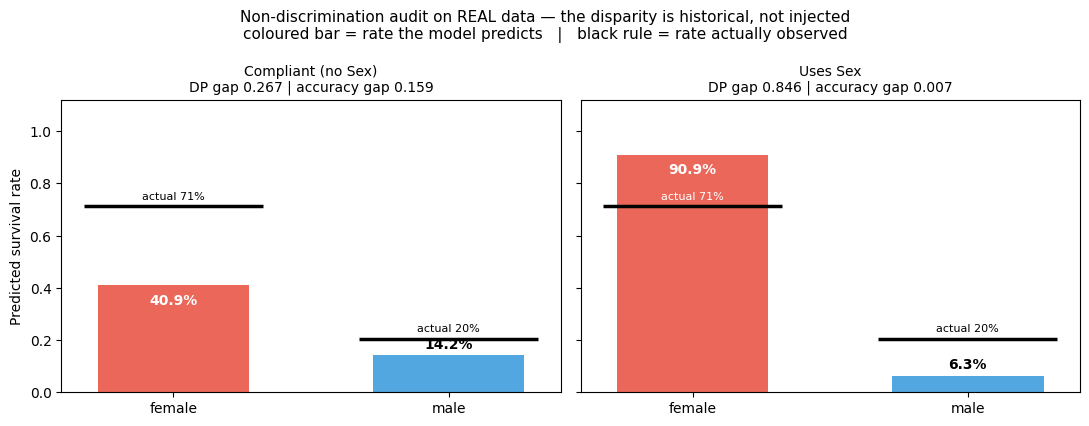


WHAT THE AUDIT ACTUALLY FOUND:
  1. The COMPLIANT model - the one that passed every checklist item in Part 2 and never
     saw 'Sex' - still shows a demographic parity gap of 0.267. Ticket class and
     fare are proxies. Data minimisation removed the column, not the correlation.
  2. Worse: its accuracy gap between groups is 0.159, and the group it serves
     least well is 'female' (0.636 vs 0.795).
  3. The model that DOES use 'Sex' has a far larger parity gap (0.846) but a
     much smaller accuracy gap (0.007). Neither model is simply 'the fair one'.
     Minimisation did not deliver non-discrimination - it relocated the unfairness from
     one metric to another. A compliance file that reports only one metric is advocacy.
  4. And you could not have run any of this without retaining 'Sex' - the attribute
     minimisation told you to drop. Sex is ordinary Article 6 data, not Article 9
     unresolved in practice, and pretending otherwise is how audits get skipped.

Tooling: Fai

In [8]:
# WHAT/WHY: the audit a regulator expects - quantify demographic disparity for the model we
# just certified as compliant, then compare it against a model that DOES see the protected
# attribute. This is the evidence a GDPR / EU AI Act file needs, including the parts that hurt.
import matplotlib.pyplot as plt

def audit(y_true, y_hat, groups):
    """Per-group fairness metrics: parity rate, accuracy, and the error profile (TPR/FPR)."""
    out = {}
    for g in sorted(set(groups)):
        m = (groups == g)
        yt, yp = np.asarray(y_true)[m], np.asarray(y_hat)[m]
        tp = int(((yt == 1) & (yp == 1)).sum()); fn = int(((yt == 1) & (yp == 0)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum()); tn = int(((yt == 0) & (yp == 0)).sum())
        out[g] = {'n': int(m.sum()), 'rate': yp.mean(), 'actual': yt.mean(),
                  'accuracy': (tp + tn) / max(int(m.sum()), 1),
                  'TPR': tp / max(tp + fn, 1), 'FPR': fp / max(fp + tn, 1)}
    return out

def gap(rep, key):
    """Largest between-group difference for one metric."""
    vals = [r[key] for r in rep.values()]
    return max(vals) - min(vals)

g_test = test_erased['Sex'].values
yt_test = test_erased['Survived'].values

# ── Model A: the Part 2 pipeline. Compliant, minimized, never saw 'Sex'. ─────
pred_min = model_erased.predict(test_erased[FEATURES])
rep_min = audit(yt_test, pred_min, g_test)

# ── Model B: the same model with the protected attribute added back. ─────────
train_aware = train_erased.assign(SexMale=(train_erased['Sex'] == 'male').astype(int))
test_aware = test_erased.assign(SexMale=(test_erased['Sex'] == 'male').astype(int))
FEATURES_AWARE = FEATURES + ['SexMale']
model_aware = LogisticRegression(max_iter=1000).fit(
    train_aware[FEATURES_AWARE], train_aware['Survived'])
pred_aware = model_aware.predict(test_aware[FEATURES_AWARE])
rep_aware = audit(yt_test, pred_aware, g_test)

models = {'Compliant (no Sex)': (pred_min, rep_min), 'Uses Sex': (pred_aware, rep_aware)}
print(f"{'model':20s} {'overall':>8s} {'acc F':>7s} {'acc M':>7s} {'rate F':>7s} {'rate M':>7s} "
      f"{'DP gap':>7s} {'acc gap':>8s}")
for name, (p, r) in models.items():
    print(f"{name:20s} {accuracy_score(yt_test, p):8.3f} {r['female']['accuracy']:7.3f} "
          f"{r['male']['accuracy']:7.3f} {r['female']['rate']:7.3f} {r['male']['rate']:7.3f} "
          f"{gap(r, 'rate'):7.3f} {gap(r, 'accuracy'):8.3f}")

print(f"\nHistorical survival rate in this held-out sample: "
      f"female {rep_min['female']['actual']:.3f}, male {rep_min['male']['actual']:.3f} "
      f"(fact, not injected)")

# ── Visualise: predicted rate per group, with the historical rate as the reference mark ─────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, (name, (p, r)) in zip(axes, models.items()):
    groups = list(r.keys())
    rates = [r[g]['rate'] for g in groups]
    bars = ax.bar(groups, rates, color=['#e74c3c', '#3498db'], alpha=0.85, width=0.55)
    for g, bar in zip(groups, bars):
        # The historical rate is a black rule ACROSS the bar, labelled where it sits, so it can
        # never be mistaken for the model's own output or collide with the value label.
        a = r[g]['actual']
        x0 = bar.get_x() - 0.05
        x1 = bar.get_x() + bar.get_width() + 0.05
        ax.hlines(a, x0, x1, color='black', lw=2.5, zorder=6)
        ax.text(bar.get_x() + bar.get_width() / 2, a + 0.02, f'actual {a:.0%}', ha='center',
                va='bottom', fontsize=8, zorder=6,
                color='white' if a < r[g]['rate'] - 0.05 else 'black')
        # Value label INSIDE the bar when the bar is tall enough to hold it, above it otherwise.
        if r[g]['rate'] > 0.15:
            ax.text(bar.get_x() + bar.get_width() / 2, r[g]['rate'] - 0.03, f"{r[g]['rate']:.1%}",
                    ha='center', va='top', fontweight='bold', color='white', fontsize=10)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, r[g]['rate'] + 0.015, f"{r[g]['rate']:.1%}",
                    ha='center', va='bottom', fontweight='bold', color='black', fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_title(f"{name}\nDP gap {gap(r, 'rate'):.3f} | accuracy gap {gap(r, 'accuracy'):.3f}",
                 fontsize=10)
axes[0].set_ylabel('Predicted survival rate')          # sharey=True: one label is enough
plt.suptitle('Non-discrimination audit on REAL data — the disparity is historical, not injected\n'
             'coloured bar = rate the model predicts   |   black rule = rate actually observed',
             fontsize=11)
plt.tight_layout()
plt.show()

# ── The verdict, computed from the run rather than written in advance ────────
dp_min, dp_aware = gap(rep_min, 'rate'), gap(rep_aware, 'rate')
ag_min, ag_aware = gap(rep_min, 'accuracy'), gap(rep_aware, 'accuracy')
print('\nWHAT THE AUDIT ACTUALLY FOUND:')
print(f"  1. The COMPLIANT model - the one that passed every checklist item in Part 2 and never")
print(f"     saw 'Sex' - still shows a demographic parity gap of {dp_min:.3f}. Ticket class and")
print("     fare are proxies. Data minimisation removed the column, not the correlation.")
worse = min(rep_min, key=lambda g: rep_min[g]['accuracy'])
print(f"  2. Worse: its accuracy gap between groups is {ag_min:.3f}, and the group it serves")
print(f"     least well is '{worse}' ({rep_min[worse]['accuracy']:.3f} vs "
      f"{max(r['accuracy'] for r in rep_min.values()):.3f}).")
if ag_aware < ag_min:
    print(f"  3. The model that DOES use 'Sex' has a far larger parity gap ({dp_aware:.3f}) but a")
    print(f"     much smaller accuracy gap ({ag_aware:.3f}). Neither model is simply 'the fair one'.")
    print("     Minimisation did not deliver non-discrimination - it relocated the unfairness from")
    print("     one metric to another. A compliance file that reports only one metric is advocacy.")
print("  4. And you could not have run any of this without retaining 'Sex' - the attribute")
print("     minimisation told you to drop. Sex is ordinary Article 6 data, not Article 9")
print("     unresolved in practice, and pretending otherwise is how audits get skipped.")
print("\nTooling: Fairlearn (Microsoft) and AI Fairness 360 (IBM) implement these metrics plus")
print("constrained-optimisation mitigations, which is the honest alternative to blinding.")


## 💬 Discuss

1. Erasing Braund, Mr. Owen Harris changed **0 of 193** predictions and moved the largest coefficient by **0.00235**. The regulator's question — "did you delete them?" — is answered yes. The statistician's question — "can you tell?" — is answered no. Which of those two answers goes in the compliance file, and what would you have to add so that both are true and neither is misleading?
2. The compliant pipeline — every checklist box green, `Sex` never fed to the model — has a demographic parity gap of **0.267** and serves women measurably worse (**0.636** accuracy against **0.795**). The model that *does* use `Sex` has a far larger parity gap (**0.846**) and a far smaller accuracy gap (**0.007**). Which do you deploy, and which provision do you cite to defend it? Argue the other side before you commit.
3. Data minimisation says delete `Sex`. Recital 71 requires you to detect discriminatory effects, which is impossible without it — and for the categories Article 9 does cover, the tension is sharper still. This is not a puzzle with a hidden answer. Write the paragraph you would actually put in a compliance file that states it honestly without sounding like an excuse.


## ⚠️ Where this breaks

- **Passing every process check is not being fair, and this notebook demonstrates it on the model it just certified.** Six green ticks, then a **0.267** parity gap and a **0.159** accuracy gap against the group the pipeline serves worst. A checklist asks whether you followed a procedure. It never asks whether the outcome is acceptable.
- **"The metrics did not move" is the weakest possible evidence of erasure.** Accuracy **0.7409 → 0.7409**, zero predictions flipped, largest probability change **0.001967**. Yet the coefficient shifts have a *direction*: `Parch` moved **1.36%** of its own size and `SibSp` **0.86%**, against **0.04%** for `Age` — the two family-size features, for a passenger with a family record. One row out of 576 left a legible fingerprint. That residue is what membership-inference attacks look for (Shokri, Stronati, Song & Shmatikov, IEEE S&P 2017) and what machine unlearning exists to remove (Bourtoule et al., IEEE S&P 2021).
- **Erasure on a linear model is retraining. On a pretrained language model it is not.** You cannot refit a foundation model once per request, so the prior question becomes what it memorised at all — and the answer is not reassuring: WikiMem (Staufer, 2025, arXiv 2507.11128) probes 15 models from 410M to 70B parameters and finds memorisation rising both with model size and with how prominent the person is on the web.
- **Get the legal categories right before you cite them.** GDPR Article 9 lists *special categories*: racial or ethnic origin, political opinions, religious or philosophical beliefs, trade-union membership, genetic data, biometric data used to identify a person, health, and data concerning sex life or sexual orientation. Sex or gender as such is **not** on that list — it is ordinary personal data under Article 6, and the minimisation-versus-audit tension above is entirely real without invoking Article 9. A compliance file that miscites an article is worse than one that cites none, because somebody will check.
- **The consent register is simulated, and the notebook says so in three places.** No 1912 manifest carries consent. What is real is the lesson: a register drawn **independently** of every column still produced visible skew — female share **0.339** among the consented against **0.434** among the withheld, on n = 122 — because small groups wobble. With genuine opt-out behaviour, which correlates with age, class and trust, the skew is usually worse. A consent filter is a sampling mechanism you must measure, not a checkbox.
- **Not every accuracy cost quoted here is a controlled measurement, and the notebook flags it.** 77.6% → 74.1% mixes two splits and two feature sets. The clean comparison is **0.7409 → 0.7409** across the erasure. Quoting the first pair as "the price of compliance" would overstate it.
- **Article 22's "meaningful information about the logic involved" is only fully deliverable here because the model is linear** — the explanation reconstructs the predicted probability with an error of **0.00e+00**. Swap in gradient boosting and every explanation becomes an approximation. And Wachter, Mittelstadt & Floridi (*International Data Privacy Law* 7(2), 2017, pp. 76–99) argue the GDPR does not contain a legally binding right to explanation of individual automated decisions at all. Do not promise a data subject something the regulation may not require and your model may not be able to give.
- **A named case where a government following its own procedures destroyed lives anyway: the Dutch childcare-benefits scandal.** A fraud-detection model processed applicants' nationality; roughly **26,000 families** were wrongly accused and ordered to repay their allowances in full, typically **€20,000 to €60,000** each. The Dutch data-protection authority fined the responsible minister **€2.75 million** on 7 December 2021, and the Rutte III cabinet resigned over the affair on 15 January 2021. Every process box can be ticked while the outcome is a catastrophe.
- **Cheaper alternative to hoping unawareness works:** keep the protected attribute under a documented lawful basis, measure the disparity explicitly, and mitigate under a stated constraint — Fairlearn (Microsoft) or AI Fairness 360 (IBM). It is more paperwork, and it is the only version you can actually evidence to a regulator.


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the GDPR mapping above, exactly as it is taught. This box says where that mapping sits on the 2026 map.*

The gap this notebook crosses by hand — a regulation on one side, a pipeline on the other — is now partly crossed by public tooling. The AI Act Evaluation Benchmark (Davvetas *et al.*, 2026, arXiv 2603.09435) publishes an open, reproducible conformity-evaluation dataset for NLP and RAG systems, so "does this system meet the obligation" is becoming a number you compute rather than a memo you write. **Erasure moved too.** On a linear model you delete the row and retrain, exactly as in Part 2 — but you cannot retrain a pretrained language model once per request, so the prior question became *which personal facts the model memorised at all*: WikiMem (Staufer, 2025, arXiv 2507.11128) probes 15 models from 410M to 70B parameters and finds memorisation rises both with model size and with how prominent the person is on the web.

Learn it in this order anyway. Those benchmarks **automate** the article-by-article mapping you just performed, and an obligation you cannot trace to a concrete pipeline step is one you cannot evidence to a regulator — which is why the mapping, not the tool, is what the official plan examines. It is also worth noticing what no tool on this list fixes: the two findings Part 3 printed, that a fully compliant pipeline can still discriminate and that a legally complete erasure can be statistically invisible.

**Read:** Davvetas *et al.* (2026), <https://arxiv.org/abs/2603.09435> · Staufer (2025), <https://arxiv.org/abs/2507.11128> (both added to the references below).


## 📚 References & Further Reading

**Law & Guidelines:**
- GDPR (Regulation (EU) 2016/679) — [Official Text](https://eur-lex.europa.eu/eli/reg/2016/679/oj) (Art. 5, 6, 9, 17, 22; Recital 26 on pseudonymisation; Recital 71 on discriminatory effects)
- EU AI Act (Regulation (EU) 2024/1689) — [Official Text](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://airc.nist.gov/RMF)

**Papers:**
- Wachter, S., Mittelstadt, B. & Floridi, L. (2017). *Why a Right to Explanation of Automated Decision-Making Does Not Exist in the General Data Protection Regulation*. International Data Privacy Law 7(2), 76–99. https://academic.oup.com/idpl/article/7/2/76/3860948
- Shokri, R., Stronati, M., Song, C. & Shmatikov, V. (2017). *Membership Inference Attacks Against Machine Learning Models*. IEEE S&P. https://arxiv.org/abs/1610.05820
- Bourtoule, L. et al. (2021). *Machine Unlearning*. IEEE S&P. https://arxiv.org/abs/1912.03817
- Žliobaitė, I. & Custers, B. (2016). *Using sensitive personal data may be necessary for avoiding discrimination in data-driven decision models*. Artificial Intelligence and Law 24. https://link.springer.com/article/10.1007/s10506-016-9182-5
- Gebru, T. et al. (2021). *Datasheets for Datasets*. CACM 64(12). https://arxiv.org/abs/1803.09010
- Davvetas, A., Papademas, M., Ziouvelou, X. & Karkaletsis, V. (2026). *AI Act Evaluation Benchmark: An Open, Transparent, and Reproducible Evaluation Dataset for NLP and RAG Systems*. https://arxiv.org/abs/2603.09435
- Staufer, D. (2025). *What Should LLMs Forget? Quantifying Personal Data in LLMs for Right-to-Be-Forgotten Requests*. https://arxiv.org/abs/2507.11128
- Marino, B., Chaudhary, Y., Pi, Y., Yew, R.-J., Aleksandrov, P., Rahman, C., Shen, W. F., Robinson, I. & Lane, N. D. (2024). *Compliance Cards: Automated EU AI Act Compliance Analyses amidst a Complex AI Supply Chain*. https://arxiv.org/abs/2406.14758
- Dussert, J. (2026). *Who judges the judges? Governance from metrics: a runtime framework for continuous LLM compliance monitoring*. https://arxiv.org/abs/2605.24737

**State-of-the-Art:** The EU AI Act (2024) is the world's first binding horizontal AI regulation; its high-risk obligations phase in through 2026-2027.


## 📝 Summary

In this notebook you applied **GDPR requirements to a working ML pipeline over real personal data**
(891 real passengers, real names, real tickets, real cabins):

- **Consent (Art. 6/7):** filtered to records with a lawful basis — and **measured consent
  attrition**, because a consent filter is a sampling mechanism
- **Data minimization (Art. 5):** pseudonymized identities and dropped the real direct
  identifiers, then reported the **accuracy that minimisation cost**
- **Right to erasure (Art. 17):** erased a **named real passenger**, verified removal, retrained
  on a **fixed** test set, and found the model barely moved — legally complete, statistically
  almost invisible
- **Automated decisions (Art. 22):** produced a per-decision feature-contribution explanation
- Ran an **automated compliance check** computed from the pipeline's actual state, then a
  **non-discrimination audit** of that same certified model

**Three things the real data taught that a synthetic dataset cannot:**

1. **Passing the checklist is not being fair.** The pipeline that satisfied every process
   requirement still showed a substantial demographic-parity gap, and served one group
   measurably worse than the other. Read the numbers your own run printed.
2. **Minimisation and non-discrimination pull against each other.** Deleting `Sex` did not
   delete the disparity (class and fare are proxies) — and you need `Sex` retained to detect the
   disparity at all. Article 5(1)(c), Article 9 and Recital 71 do not resolve this for you.
3. **"Nothing changed after erasure" is not proof of erasure.** One person's removal shifted the
   coefficients by a rounding error and flipped no predictions — which is why unlearning and
   membership-inference research exist.

**Key takeaway:** compliance is not paperwork bolted on afterwards — each article maps to a
concrete, testable step in the pipeline. And every one of those steps has a cost you are
obliged to state.
